In [1]:
%load_ext autoreload
%autoreload 2

# ignore warnings for readability
import warnings
warnings.filterwarnings('ignore')

import os
from os.path import join
from collections import defaultdict
import numpy as np
import pandas as pd
import tqdm
from sklearn.linear_model import LinearRegression

import logging
logging.getLogger('fontTools.subset').setLevel(logging.WARNING)

# matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.style.use('euclid_stylesheet_v2.mplstyle')
mpl.rcParams['figure.dpi'] = 300

In [2]:
mdir = './saved_models'


def r2logm(r):
    # see preprocessing.ipynb for this measurement
    coef = 0.36752
    intercept = -5.30640
    return (np.log10(r)-intercept)/coef

In [3]:
datanames = ['wC50', 'wC100', 'dC50', 'dC100']
runnames = ['base', 'gals_nle', 'summ_nle', 'gnn_npe']
modelnames = ['msig', 'pamico', 'mamp', 'gals_nle', 'summ_nle', 'gnn_npe']
Nfolds = 10
folds = np.arange(Nfolds)

datatitles = dict(
    wC50='Wide $50\%$',
    wC100='Wide $100\%$',
    dC50='Deep $50\%$',
    dC100='Deep $100\%$'
)
modeltitles = dict(
    msig='$M$--$\sigma$',
    pamico=r'$M$--$\lambda_{\rm spec}$',
    mamp='MAMPOSSt',
    gals_nle='Galaxy-Net',
    summ_nle='Summary-Net',
    gnn_npe='Graph-Net',
    true='True',
    prior='Prior',
    dummy='Dummy'
)

In [4]:
from scipy.stats import skewnorm
from scipy.optimize import minimize


def fit_skewed_normal(p16, p50, p84):
    target_percentiles = [0.16, 0.50, 0.84]
    observed_values = [p16, p50, p84]

    def objective(params):
        loc, scale, alpha = params
        if scale <= 0:
            return np.inf
        skewed_gaussian = skewnorm(alpha, loc=loc, scale=scale)
        calculated_values = skewed_gaussian.ppf(target_percentiles)
        return np.sum((calculated_values - observed_values) ** 2)

    initial_guess = [p50, (p84 - p16) / 2, 0.5]
    result = minimize(objective, initial_guess)
    loc, scale, alpha = result.x
    return skewnorm(alpha, loc=loc, scale=scale)

In [5]:
# load train/test
header = 'APR24'
datadir = './data/processed'

theta, fold, ids, richs, zclus, Ngal = {}, {}, {}, {}, {}, {}
for d in datanames:
    dirpath = join(datadir, f'{header}{d}')
    print('Loading:', dirpath)
    theta[d] = np.load(join(dirpath, 'theta_batch.npy'))
    fold[d] = np.load(join(dirpath, 'folds_batch.npy'))
    ids[d] = np.load(join(dirpath, 'ids_batch.npy'))
    metas = np.load(join(dirpath, 'metas_batch.npy'))
    zclus[d] = metas[:, 3]  # cluster photometric redshift
    richs[d] = metas[:, 1]  # sum of AMICO photometry
    Ngal[d] = np.load(join(dirpath, 'x_sum.npy'))[:, -1]

Ndata = {d: len(theta[d]) for d in datanames}
print(Ndata)

Loading: ./data/processed/APR24wC50
Loading: ./data/processed/APR24wC100
Loading: ./data/processed/APR24dC50
Loading: ./data/processed/APR24dC100
{'wC50': 840, 'wC100': 907, 'dC50': 1998, 'dC100': 2014}


In [6]:
Nsamp = 100
preds = defaultdict(dict)
for d in datanames:
    for r in runnames:
        # setup
        if r == 'base':
            preds[d]['msig'] = np.ones((Ndata[d], 2))*np.nan
            preds[d]['pamico'] = np.ones((Ndata[d], 2))*np.nan
        else:
            preds[d][r] = np.full((Ndata[d], Nsamp, 1), np.nan)

        # load
        for f in folds:
            if r == 'gnn_npe':
                dirname = f'oct02_{r}_{d}_f{f}'
            else:
                dirname = f'apr24_{r}_{d}_f{f}'
            if r == 'base':
                # Msig
                samplefile = join(mdir, dirname, 'msig.npz')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                place_ids = np.searchsorted(ids[d], s['ids'])
                np.put(preds[d]['msig'][:, 0], place_ids, s['pred'])
                np.put(preds[d]['msig'][:, 1], place_ids, s['std'])

                # Pamico
                samplefile = join(mdir, dirname, 'Pamico.npz')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                place_ids = np.searchsorted(ids[d], s['ids'])
                np.put(preds[d]['pamico'][:, 0], place_ids, s['pred'])
                np.put(preds[d]['pamico'][:, 1], place_ids, s['std'])

            else:
                # ML models
                samplefile = join(mdir, dirname, 'posterior_samples.npy')
                if not os.path.exists(samplefile):
                    print(f'Skipping {dirname}')
                    continue
                s = np.load(samplefile)
                s = np.swapaxes(s, 0, 1)
                s = s[:, :Nsamp]  # subsample if necessary
                preds[d][r][fold[d] == f] = s

In [7]:
# load mamposst

mamnames = {
    'wC50': 'wide50', 'wC100': 'wide100', 'dC50': 'deep50', 'dC100': 'deep100'
}
modeldir = './saved_models/mamposst_newprior_dec1824/'

for k, v in mamnames.items():
    isamp = pd.read_csv(join(modeldir, f'result_MockFS_NewAMICO_{v}.dat'),
                        delimiter=' ', skipinitialspace=True)
    isamp['id'] = isamp['#ClusterID'].astype(int)
    # convert r200 to logm
    for c in isamp.columns:
        if 'r200' not in c:
            continue
        isamp['logm'+c[4:]] = r2logm(isamp[c])

    # put in preds
    preds[k]['mamp'] = np.ones((Ndata[k], 5))*np.nan
    place_ids = np.searchsorted(ids[k], isamp['id'].values)
    mask = place_ids < Ndata[k]
    _s = isamp[['logmlow(68)', 'logmup(68)', 'logmlow(95)',
                'logmup(95)', 'logmMAM']].values
    preds[k]['mamp'][place_ids[mask]] = _s[mask]

In [8]:
# calculate percentiles from predictions
q = 100*np.array([0.16, 0.84, 0.5, 0.025, 0.975])
percs = defaultdict(dict)
for d in datanames:
    for m in modelnames:
        if m == 'msig' or m == 'pamico':
            t_ = preds[d][m]
            percs[d][m] = np.stack(
                [t_[:, 0]-t_[:, 1], t_[:, 0]+t_[:, 1], t_[:, 0],
                    t_[:, 0]-2*t_[:, 1], t_[:, 0]+2*t_[:, 1]],
                axis=1).T
        elif m == 'mamp':
            if m not in preds[d]:
                continue
            t_ = preds[d][m]
            percs[d][m] = np.stack(
                [t_[:, 0], t_[:, 1], t_[:, 4], t_[:, 2], t_[:, 3]],
                axis=1).T
        else:
            t_ = preds[d][m]
            percs[d][m] = np.percentile(t_, q, axis=1)[..., 0]
# percs is of shape (5, Ndata)
# dim 0 is of order [16, 84, 50, 2.5, 97.5]

In [9]:
# Compute quality control
def quality_control(percs):
    # checks if we have a reasonable median prediction
    # checks if we're not missing a prediction (not nan)
    med = percs[2]
    mask = (med > 12) & (med < 16)

    err = (percs[1] - percs[0])/2
    mask &= err < 1
    return mask


qc = defaultdict(dict)
for d in datanames:
    for m in modelnames:
        qc[d][m] = quality_control(percs[d][m])

In [10]:
# Remove Ngal < 3
for d in datanames:
    mask = Ngal[d] >= 3

    theta[d] = theta[d][mask]
    fold[d] = fold[d][mask]
    ids[d] = ids[d][mask]
    richs[d] = richs[d][mask]
    zclus[d] = zclus[d][mask]
    Ngal[d] = Ngal[d][mask]
    Ndata[d] = len(theta[d])

    for m in modelnames:
        if m not in percs[d]:
            continue
        preds[d][m] = preds[d][m][mask]
        percs[d][m] = percs[d][m][:, mask]
        qc[d][m] = qc[d][m][mask]

## MCMC

Inverse parametrization of the mass-richness relation (see `8_appendix.tex`).
We model $p(m\,|\,\lambda, z, \theta)$ and reweight each mass posterior sample
by $p(m|\theta,\lambda,z)/p(m)$, where $p(m)$ is the inference prior.
Parameters: $\theta = \{m_0, F_\lambda, G_z, \sigma_{\rm int}\}$
(named `A, B, C, sigl` in code).

In [11]:
# LinearRegression to estimate the INVERSE relation: m | lambda, z
# (used to seed the prior on sigma_int; see 8_appendix.tex)
d = 'dC100'
rs = richs[d]
zs = zclus[d]
ytrue = theta[d][:, 0]

# pivots
l0, z0 = 15, 1.0

# regress m on log10(lambda/l0) and log10((1+z)/(1+z0))
X = np.stack([np.log10(rs/l0), np.log10((1+zs)/(1+z0))], axis=1)
reg = LinearRegression().fit(X, ytrue)
residual_std = np.std(ytrue - reg.predict(X))
print(f'm0 (intercept): {reg.intercept_:.3f}')
print(f'F_lambda (richness slope): {reg.coef_[0]:.3f}')
print(f'G_z (redshift slope): {reg.coef_[1]:.3f}')
print(f'sigma_int (residual std): {residual_std:.3f}')

m0 (intercept): 13.567
F_lambda (richness slope): 1.268
G_z (redshift slope): -2.949
sigma_int (residual std): 0.262


In [12]:
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import corner

# Inverse (appendix) parametrization, see 8_appendix.tex.
# The mass-richness relation p(m | lambda, z, theta) is Gaussian in mass:
#   <m | lambda, z> = m0 + F_lambda*log10(lambda/l0) + G_z*log10((1+z)/(1+z0))
# Each mass posterior sample is reweighted by p(m|theta,lambda,z)/p(m), where
# p(m) ~ N(m0_prior, sig0^2) is the prior assumed in the mass inference.
# theta = {A=m0, B=F_lambda, C=G_z, sigl=sigma_int}.


def mlamb_mean(lambs, zs, l0, z0, A, B, C):
    # mean mass <m | lambda, z>
    return A + B*(jnp.log10(lambs/l0)) + C*(jnp.log10((1+zs)/(1+z0)))


def operand(m, lambs, zs, l0, z0, m0, sig0, sigl, A, B, C):
    # Delta_i(m, theta): log of p(m|theta,lambda,z)/p(m) up to constants
    t1 = (m-m0)**2/(2*(sig0**2))
    mest = mlamb_mean(lambs, zs, l0, z0, A, B, C)
    t2 = (m - mest[:, None])**2/(2*(sigl**2))
    return t1 - t2


def log_likelihood(samps, lambs, zs, l0, z0, m0, sig0, sigl, A, B, C):
    Nclu, Nsamp = samps.shape
    to_sum = operand(samps, lambs, zs, l0, z0, m0, sig0, sigl, A, B, C)
    summed = logsumexp(to_sum, axis=1)   # LSE over mass samples, (Nclu,)
    out = -Nclu*jnp.log(sigl) - Nclu*jnp.log(Nsamp) + jnp.sum(summed)
    return out


def model(samps, lambs, zs, l0, z0, m0, sig0):
    A = numpyro.sample("A", dist.Uniform(5, 20))
    B = numpyro.sample("B", dist.Uniform(-10, 10))
    C = numpyro.sample("C", dist.Uniform(-10, 10))
    sigl = numpyro.sample("sigl", dist.LogUniform(1e-2, 0.6))

    numpyro.factor(
        "log_likelihood",
        log_likelihood(samps, lambs, zs, l0, z0, m0, sig0, sigl, A, B, C))


def run_mcmc(samps, lambs, zs, l0, z0, m0, sig0,
             warmup=500, samples=1000, chains=4):
    mcmc = MCMC(NUTS(model), num_warmup=warmup,
                num_samples=samples, num_chains=chains)
    mcmc.run(jax.random.PRNGKey(0), samps=samps, lambs=lambs,
             zs=zs, l0=l0, z0=z0, m0=m0, sig0=sig0)
    return mcmc.get_samples()

In [13]:
# ============================================================
# Likelihood playground -- set the knobs here
# ============================================================
d = 'dC100'        # dataset: wC50, wC100, dC50, dC100
m = 'gnn_npe'      # mass model: msig, pamico, mamp, gals_nle, summ_nle,
#             gnn_npe, true, dummy
l0, z0 = 15, 0.82           # richness and redshift pivots
m0, sig0 = 13.78, 0.348      # assumed mass prior p(m) ~ N(m0, sig0^2)
# ============================================================

rs = richs[d]
zs = zclus[d]
ytrue = theta[d][:, 0]

# build mass posterior samples `samps` of shape (Nclu, Nsamp)
if m in ['msig', 'pamico']:
    mu, sig = preds[d][m].T
    samps = mu[:, None] + sig[:, None]*np.random.randn(len(mu), Nsamp)
elif m == 'mamp':
    ps = preds[d][m]
    p16, p84, p50 = ps[:, 0], ps[:, 1], ps[:, 4]
    samps = np.array([
        fit_skewed_normal(p16[i], p50[i], p84[i]).rvs(Nsamp)
        if not np.isnan(p16[i]) else np.full(Nsamp, np.nan)
        for i in tqdm.tqdm(range(len(p16)))
    ])
elif m == 'dummy':
    # synthetic posteriors for testing the likelihood: noisy + prior-shrunk
    sigma_n = 0.3               # injected noise (dex)
    post_var = 1.0/(1.0/sigma_n**2 + 1.0/sig0**2)
    x = ytrue + sigma_n*np.random.randn(len(ytrue))
    post_mean = post_var*(x/sigma_n**2 + m0/sig0**2)
    samps = (post_mean[:, None]
             + np.sqrt(post_var)*np.random.randn(len(ytrue), Nsamp))
    qc[d]['dummy'] = qc[d]['gnn_npe']
elif m == 'prior':
    samps = np.random.randn(len(ytrue), Nsamp) * sig0 + m0
    qc[d]['prior'] = qc[d]['gnn_npe']
elif m == 'true':
    samps = ytrue[:, None]
    qc[d]['true'] = qc[d]['gnn_npe']
else:
    samps = preds[d][m][..., 0]

# quality control
mask = qc[d][m]
rs, zs, samps, ytrue = rs[mask], zs[mask], samps[mask], ytrue[mask]

print('samps shape:', samps.shape)
print('true mass mean/std:', ytrue.mean(), ytrue.std())

samps shape: (2014, 100)
true mass mean/std: 13.776200370712232 0.3479471949306839


In [14]:
# Run MCMC
samples = run_mcmc(samps, rs, zs, l0, z0, m0, sig0, samples=2000, chains=2)
print(samps.mean())

sample: 100%|██████████| 2500/2500 [00:10<00:00, 231.29it/s, 7 steps of size 4.02e-01. acc. prob=0.91] 


13.780167335692086


In [15]:
# Run MCMC with true masses for reference
truesamples = run_mcmc(ytrue[:, None], rs, zs, l0,
                       z0, m0, sig0, samples=2000, chains=2)
print(ytrue.mean(), ytrue.std())

sample: 100%|██████████| 2500/2500 [00:01<00:00, 2321.71it/s, 11 steps of size 3.11e-01. acc. prob=0.92]

13.776200370712232 0.3479471949306839


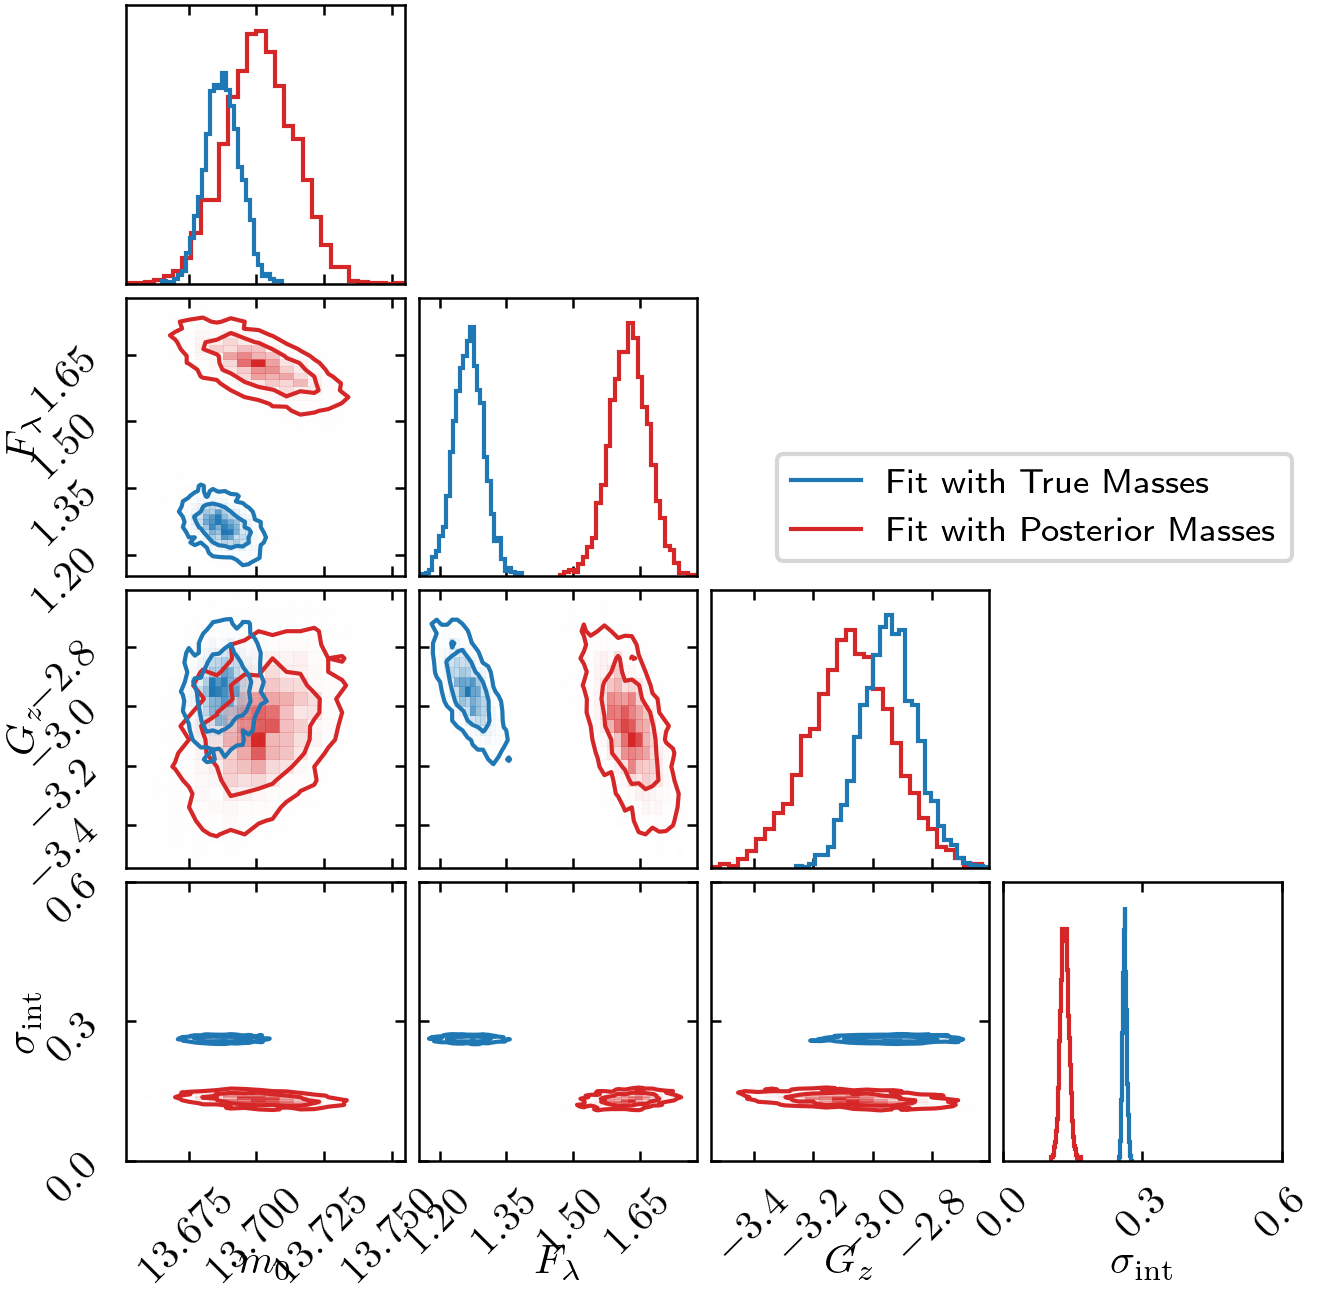

In [16]:
# plot the corner plot
fig = plt.figure(figsize=(4.5, 4.5))

# parameter ranges; set to a list of (lo, hi) per param to fix the axes
ranges = None

# Fit with Posterior Masses
data = np.vstack(
    [samples['A'], samples['B'], samples['C'], samples['sigl']]
).T
corner.corner(
    data,
    labels=[r"$m_0$", r"$F_\lambda$", r"$G_z$", r"$\sigma_{\rm int}$"],
    levels=[0.68, 0.95],
    range=ranges,
    fig=fig,
    color='C3',
    alpha=0.1, plot_contours=True,  # smooth=0.5, smooth1d=0.5,
    hist_bin_factor=1.5,
    plot_datapoints=False, no_fill_contours=True
)

# Fit with True Masses
data = np.vstack(
    [truesamples['A'], truesamples['B'], truesamples['C'], truesamples['sigl']]
).T
corner.corner(
    data,
    labels=[r"$m_0$", r"$F_\lambda$", r"$G_z$", r"$\sigma_{\rm int}$"],
    levels=[0.68, 0.95],
    range=ranges,
    fig=fig,
    color='C0',
    plot_contours=True,  # smooth=0.5, smooth1d=0.5,
    hist_bin_factor=1.5,
    plot_datapoints=False, no_fill_contours=True,
)

# set yticks manually on the bottom-left subplots
for ax in fig.axes[-4:-1]:
    ax.set_yticks([0, 0.3, 0.6])
fig.axes[-1].set_xticks([0, 0.3, 0.6])

plt.plot([], [], color='C0', label='Fit with True Masses')
plt.plot([], [], color='C3', label='Fit with Posterior Masses')

# Add the legend
plt.legend(loc='upper right', bbox_to_anchor=(1.1, 2.6), fontsize='small')

# fig.savefig(f'figures/mlambda_corner_{d}.pdf', bbox_inches='tight')

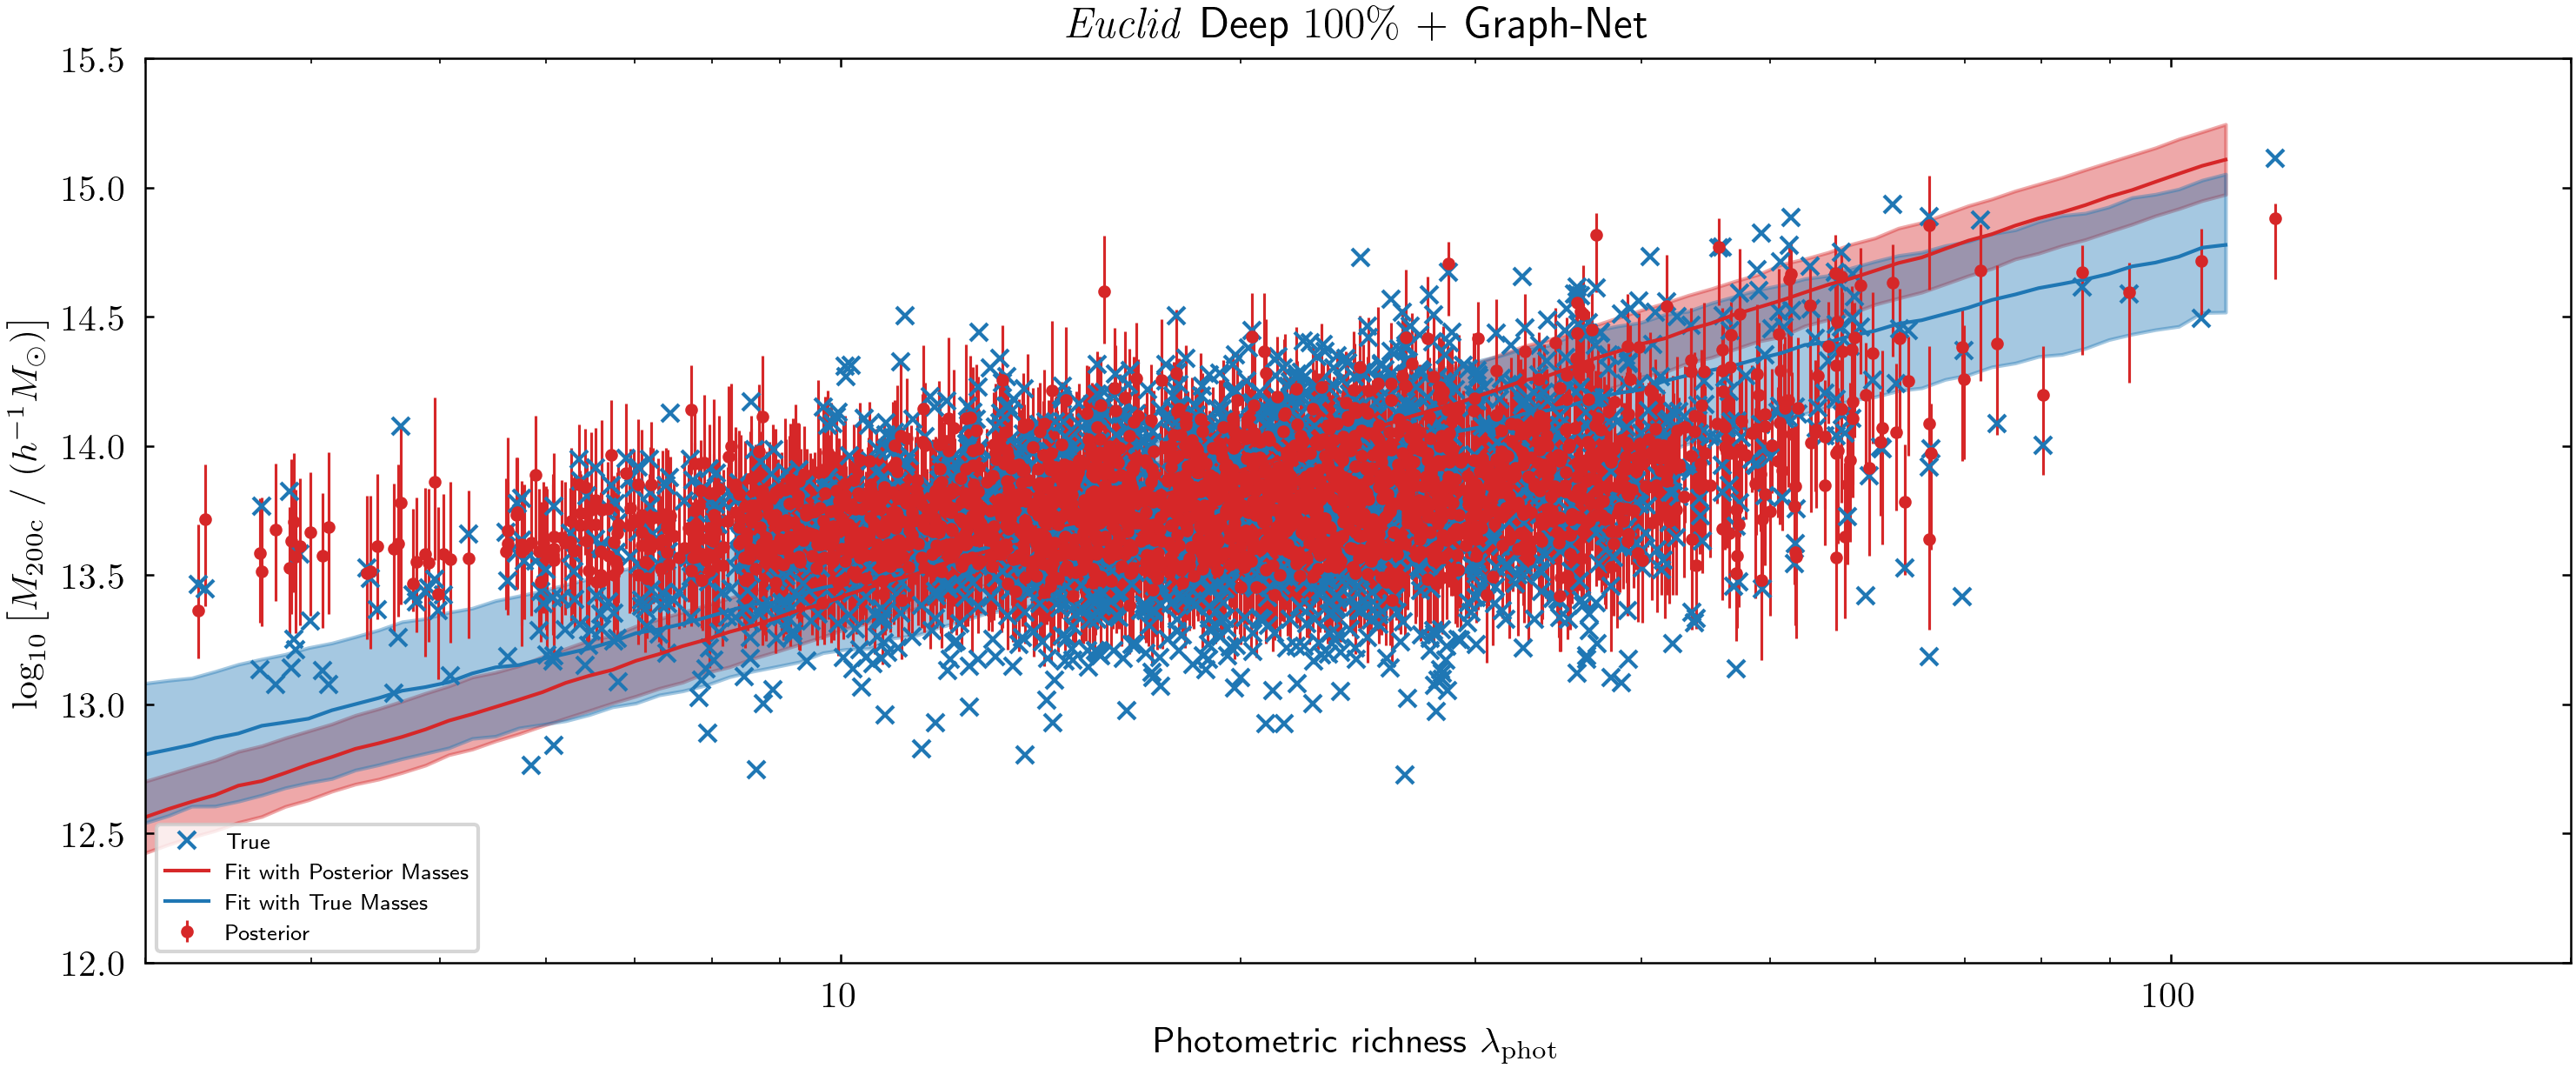

In [20]:
# Mass--richness fit: mass (y) as a function of richness (x)
f, ax = plt.subplots(1, 1, figsize=(12, 4.5))
ax.semilogx()

# posterior mass samples (median + 16/84) vs richness
p_ = np.percentile(samps, [16, 50, 84], axis=1)
ax.errorbar(rs, p_[1], yerr=[p_[1]-p_[0], p_[2]-p_[1]],
            fmt='.', label='Posterior', alpha=1, elinewidth=0.75, color='C3')

# true masses vs richness
ax.plot(rs, ytrue, 'x', label='True', alpha=1, markersize=5, color='C0')

# fit grid in richness, evaluated at the redshift pivot
x = 10**np.linspace(np.log10(2), np.log10(110), 100)

# fit with posterior masses, and with true masses (for reference)
for s, color, lab in [(samples, 'C3', 'Fit with Posterior Masses'),
                      (truesamples, 'C0', 'Fit with True Masses')]:
    lines = mlamb_mean(x[:, None], z0, l0, z0, s['A'], s['B'], s['C'])
    lines = lines + s['sigl']*np.random.randn(*lines.shape)
    p_ = np.percentile(lines, [16, 50, 84], axis=1)
    ax.plot(x, p_[1], label=lab, c=color)
    ax.fill_between(x, p_[0], p_[2], alpha=0.4, color=color)

ax.set_xlim(3, 200)
ax.set_ylim(12., 15.5)
ax.set_xlabel(r'Photometric richness $\lambda_{\rm phot}$')
ax.set_ylabel(r'$\log_{10}\left[M_{\rm 200c}\ /\ (h^{-1}M_{\odot})\right]$')
ax.set_title(f'$\it{{Euclid}}$ {datatitles[d]} + {modeltitles[m]}')
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.legend(loc='lower left', fontsize=6)

# f.savefig(f'figures/mlambda_fit_{d}.pdf', bbox_inches='tight')

Mean ESS: 49.8 out of 100 samples
Minimum ESS: 1.0
Clusters with ESS < 10 (Danger Zone): 38


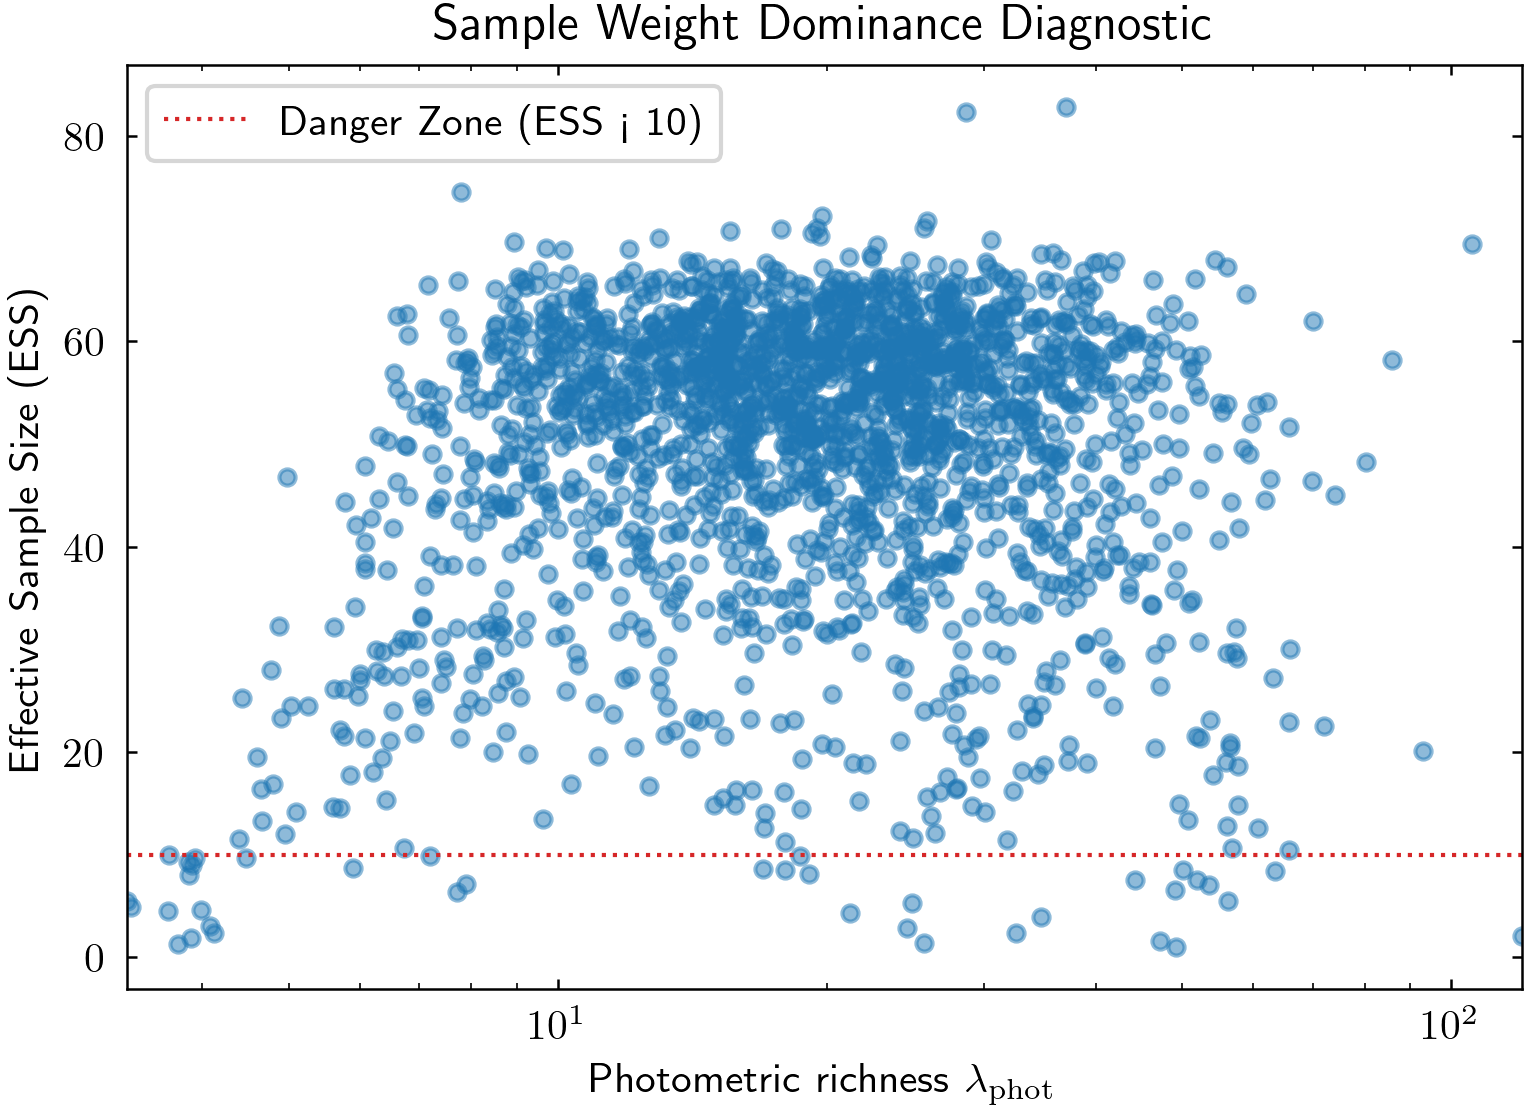

In [21]:
# Calculate median parameters from the existing MCMC samples
med_A = np.median(samples['A'])
med_B = np.median(samples['B'])
med_C = np.median(samples['C'])
med_sigl = np.median(samples['sigl'])

# Evaluate the operand to get log-weights using the median fit
log_weights = operand(samps, rs, zs, l0, z0, m0, sig0,
                      med_sigl, med_A, med_B, med_C)

# Convert to normalized weights safely to prevent overflow
log_w_max = np.max(log_weights, axis=1, keepdims=True)
w = np.exp(log_weights - log_w_max)
w_norm = w / np.sum(w, axis=1, keepdims=True)

# Calculate Effective Sample Size (ESS) for each cluster
ess = 1.0 / np.sum(w_norm**2, axis=1)

print(f"Mean ESS: {np.mean(ess):.1f} out of {Nsamp} samples")
print(f"Minimum ESS: {np.min(ess):.1f}")
print(f"Clusters with ESS < 10 (Danger Zone): {np.sum(ess < 10)}")

# Plot ESS vs Richness to identify where the fit is breaking
f, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(rs, ess, alpha=0.5, s=15, color='C0')
ax.axhline(10, color='C3', linestyle=':', label='Danger Zone (ESS < 10)')
ax.set_xscale('log')
ax.set_xlabel(r'Photometric richness $\lambda_{\rm phot}$')
ax.set_ylabel('Effective Sample Size (ESS)')
ax.set_title('Sample Weight Dominance Diagnostic')
ax.legend()
plt.show()

[Text(0.5, 0, 'Photometric richness $\\lambda_{\\rm phot}$'),
 Text(0, 0.5, '$\\log_{10}\\left[M_{\\rm 200c}\\ /\\ (h^{-1}M_{\\odot})\\right]$')]

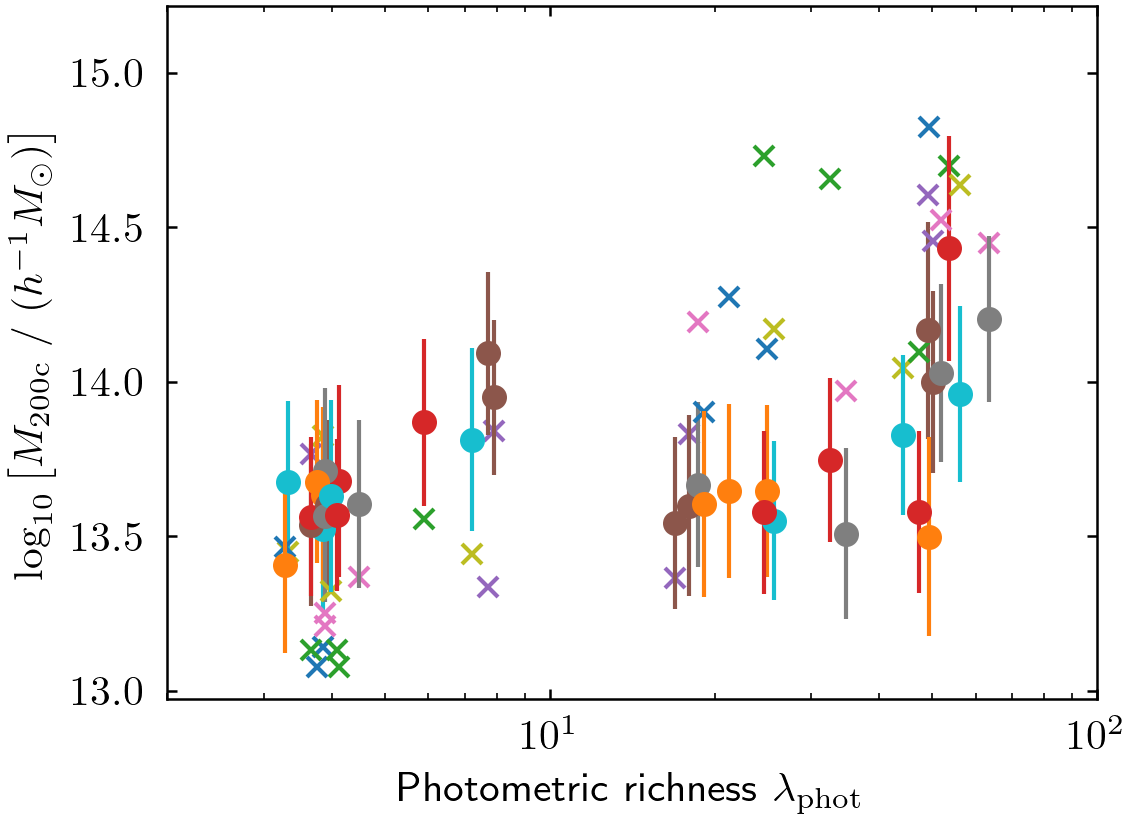

In [19]:
mask = ess < 10


f, ax = plt.subplots()
for i in np.argwhere(mask):
    ax.plot(rs[i], ytrue[i], 'x')
    ax.errorbar(rs[i], samps[i].mean(), yerr=samps[i].std(), fmt='o')

ax.semilogx()
ax.set_xlim(2, 100)
ax.set(xlabel=r'Photometric richness $\lambda_{\rm phot}$',
       ylabel=r'$\log_{10}\left[M_{\rm 200c}\ /\ (h^{-1}M_{\odot})\right]$')